In [2]:
import hoomd
import matplotlib

%matplotlib inline
matplotlib.style.use("ggplot")
import matplotlib_inline

matplotlib_inline.backend_inline.set_matplotlib_formats("svg")

In [3]:
cpu = hoomd.device.CPU()
simulation = hoomd.Simulation(device=cpu, seed=1)
simulation.create_state_from_gsd(
    filename="random.gsd"
)

integrator = hoomd.md.Integrator(dt=0.005)
cell = hoomd.md.nlist.Cell(buffer=0.4)
lj = hoomd.md.pair.LJ(nlist=cell)
lj.params[("A", "A")] = dict(epsilon=1, sigma=1)
lj.r_cut[("A", "A")] = 2.5
integrator.forces.append(lj)
nvt = hoomd.md.methods.ConstantVolume(
    filter=hoomd.filter.All(), thermostat=hoomd.md.methods.thermostats.Bussi(kT=1.5)
)
integrator.methods.append(nvt)
simulation.operations.integrator = integrator
simulation.run(0)

In [4]:
simulation.loggables

{'timestep': 'scalar',
 'seed': 'scalar',
 'tps': 'scalar',
 'walltime': 'scalar',
 'final_timestep': 'scalar',
 'initial_timestep': 'scalar'}

In [5]:
thermodynamic_properties = hoomd.md.compute.ThermodynamicQuantities(
    filter=hoomd.filter.All()
)
simulation.operations.computes.append(thermodynamic_properties)
thermodynamic_properties.loggables

{'kinetic_temperature': 'scalar',
 'pressure': 'scalar',
 'pressure_tensor': 'sequence',
 'kinetic_energy': 'scalar',
 'translational_kinetic_energy': 'scalar',
 'rotational_kinetic_energy': 'scalar',
 'potential_energy': 'scalar',
 'degrees_of_freedom': 'scalar',
 'translational_degrees_of_freedom': 'scalar',
 'rotational_degrees_of_freedom': 'scalar',
 'num_particles': 'scalar',
 'volume': 'scalar'}

In [6]:
simulation.timestep

11000

In [7]:
thermodynamic_properties.kinetic_temperature

1.519613235933732

In [8]:
logger = hoomd.logging.Logger(categories=["scalar", "sequence"])

In [9]:
logger.add(thermodynamic_properties)

In [10]:
logger.add(simulation, quantities=["timestep", "walltime"])

## Writing Log Quantities to a File

In [11]:
hdf5_writer = hoomd.write.HDF5Log(
    trigger=hoomd.trigger.Periodic(1000), filename="log.h5", mode="x", logger=logger
)
simulation.operations.writers.append(hdf5_writer)

In [12]:
simulation.run(100_000)

In [13]:
simulation.operations.writers.remove(hdf5_writer)

## Reading Logged Data From a HDF5 File

In [14]:
!h5ls -r log.h5

/                        Group
/hoomd-data              Group
/hoomd-data/Simulation   Group
/hoomd-data/Simulation/timestep Dataset {100/Inf}
/hoomd-data/Simulation/walltime Dataset {100/Inf}
/hoomd-data/md           Group
/hoomd-data/md/compute   Group
/hoomd-data/md/compute/ThermodynamicQuantities Group
/hoomd-data/md/compute/ThermodynamicQuantities/degrees_of_freedom Dataset {100/Inf}
/hoomd-data/md/compute/ThermodynamicQuantities/kinetic_energy Dataset {100/Inf}
/hoomd-data/md/compute/ThermodynamicQuantities/kinetic_temperature Dataset {100/Inf}
/hoomd-data/md/compute/ThermodynamicQuantities/num_particles Dataset {100/Inf}
/hoomd-data/md/compute/ThermodynamicQuantities/potential_energy Dataset {100/Inf}
/hoomd-data/md/compute/ThermodynamicQuantities/pressure Dataset {100/Inf}
/hoomd-data/md/compute/ThermodynamicQuantities/pressure_tensor Dataset {100/Inf, 6}
/hoomd-data/md/compute/ThermodynamicQuantities/rotational_degrees_of_freedom Dataset {100/Inf}
/hoomd-data/md/compute/Thermo

In [15]:
!h5dump -d /hoomd-data/md/compute/ThermodynamicQuantities/potential_energy log.h5

HDF5 "log.h5" {
DATASET "/hoomd-data/md/compute/ThermodynamicQuantities/potential_energy" {
   DATATYPE  H5T_IEEE_F64LE
   DATASPACE  SIMPLE { ( 100 ) / ( H5S_UNLIMITED ) }
   DATA {
   (0): -562.715, -524.441, -507.372, -574.948, -546.707, -532.383, -553.607,
   (7): -569.511, -564.406, -586.001, -555.725, -534.695, -548.796, -524.249,
   (14): -535.004, -544.051, -547.328, -542.357, -554.355, -535.939,
   (20): -538.935, -562.484, -559.96, -538.459, -545.831, -559.343, -543.438,
   (27): -537.494, -570.723, -526.281, -553.169, -526.84, -550.264, -551.999,
   (34): -527.653, -544.42, -535.592, -559.629, -568.817, -552.567, -568.112,
   (41): -542.876, -532.809, -555.282, -543.048, -523.909, -532.884,
   (47): -524.926, -546.05, -551.352, -565.991, -543.572, -521.404, -514.203,
   (54): -551.496, -529.344, -554.29, -549.295, -540.825, -521.684, -554.93,
   (61): -545.854, -543.746, -533.74, -547.33, -556.447, -567.413, -558.64,
   (68): -544.615, -534.525, -537.654, -536.311, -524.282,

In [16]:
hdf5_file = h5py.File(name="log.h5", mode="r")

In [17]:
hdf5_file["hoomd-data/md/compute/ThermodynamicQuantities/potential_energy"]

<HDF5 dataset "potential_energy": shape (100,), type "<f8">

In [18]:
hdf5_file["hoomd-data/md/compute/ThermodynamicQuantities/potential_energy"][:]

array([-562.71470056, -524.44123964, -507.3723401 , -574.94779648,
       -546.70688079, -532.38335471, -553.60679296, -569.51051482,
       -564.40624975, -586.0011094 , -555.72546471, -534.69468571,
       -548.79636303, -524.24921849, -535.00373266, -544.05078055,
       -547.32785125, -542.35714978, -554.35523365, -535.93899159,
       -538.93504319, -562.48385689, -559.96040913, -538.45878707,
       -545.83088815, -559.34290621, -543.43770939, -537.49375025,
       -570.7231659 , -526.28129331, -553.16907426, -526.84039159,
       -550.26393856, -551.99948228, -527.65316329, -544.42040241,
       -535.59171509, -559.62868465, -568.81742648, -552.56723644,
       -568.11167017, -542.8763503 , -532.80927741, -555.28208961,
       -543.04768736, -523.90852396, -532.88375826, -524.9261766 ,
       -546.04966645, -551.35188452, -565.99115453, -543.57180074,
       -521.40411776, -514.20279536, -551.49572824, -529.34417442,
       -554.28963329, -549.29523467, -540.82465902, -521.68360

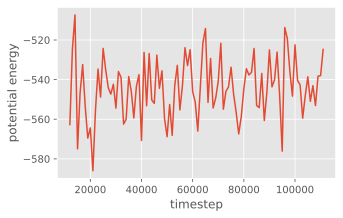

In [19]:
timestep = hdf5_file["hoomd-data/Simulation/timestep"][:]
potential_energy = hdf5_file[
    "hoomd-data/md/compute/ThermodynamicQuantities/potential_energy"
][:]

fig = matplotlib.figure.Figure(figsize=(5, 3.09))
ax = fig.add_subplot()
ax.plot(timestep, potential_energy)
ax.set_xlabel("timestep")
ax.set_ylabel("potential energy")
fig

In [20]:
hdf5_file["hoomd-data/md/compute/ThermodynamicQuantities/pressure_tensor"][0]

array([ 0.32608018, -0.02853837,  0.23730429,  0.35067439, -0.0278541 ,
        0.32433428])